In [1]:
# Example: If you uploaded my_dataset.zip directly to /content/
ZIP_FILE = "/content/drive/MyDrive/MindScan/multiclassification_dataset.zip"

# Destination folder where the extracted files will go (e.g., /content/data/)
DEST_FOLDER = "/content/MindScan/multiclass_dataset"

# Create the destination folder first
!mkdir -p {DEST_FOLDER}

# Use the unzip command
# -q makes it quiet (no long output list), -d sets the destination directory
!unzip -q {ZIP_FILE} -d {DEST_FOLDER}

print(f"Extraction complete. Data is ready in: {DEST_FOLDER}")

Extraction complete. Data is ready in: /content/MindScan/multiclass_dataset


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import trange, tqdm

In [3]:
# ===========================
# 1️⃣ CONFIGURATION
# ===========================
DATA_ROOT = "/content/MindScan/multiclass_dataset"  # Path to normalized data
TRAIN_DIR = os.path.join(DATA_ROOT, "Training")
TEST_DIR  = os.path.join(DATA_ROOT, "Testing")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 5  # Early stopping patience
BEST_MODEL_PATH = "resnet18_multiclass_tumor.pth"

In [4]:
# ===========================
# 2️⃣ CUSTOM DATASET
# ===========================
class TumorTypeDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.data, self.labels = [], []
        self.transform = transform
        self.classes = sorted(os.listdir(data_dir))
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        for cls_name in self.classes:
            cls_dir = os.path.join(data_dir, cls_name)
            if not os.path.isdir(cls_dir):
                continue
            for f in os.listdir(cls_dir):
                if f.endswith('.npy'):
                    self.data.append(os.path.join(cls_dir, f))
                    self.labels.append(self.class_to_idx[cls_name])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = np.load(self.data[idx])
        x = torch.tensor(x, dtype=torch.float32)

        # Ensure 3-channel (C, H, W)
        if x.ndim == 2:  # (H, W)
            x = x.unsqueeze(0).repeat(3, 1, 1)
        elif x.ndim == 3:
            if x.shape[0] == 1:
                x = x.repeat(3, 1, 1)
            elif x.shape[0] == 2:
                x = torch.cat([x[0:1], x], dim=0)
            elif x.shape[0] > 3:
                x = x[:3, :, :]

        if self.transform:
            x = self.transform(x)

        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

In [5]:
# ===========================
# 3️⃣ TRANSFORMS
# ===========================
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [6]:
# ===========================
# 4️⃣ LOAD DATA
# ===========================
train_dataset = TumorTypeDataset(TRAIN_DIR, transform=transform)
test_dataset  = TumorTypeDataset(TEST_DIR, transform=transform)

print("Train class counts:", Counter(train_dataset.labels))
print("Test class counts:", Counter(test_dataset.labels))

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Train class counts: Counter({2: 1457, 1: 1339, 0: 1321})
Test class counts: Counter({1: 306, 0: 300, 2: 300})


In [7]:
# ===========================
# 5️⃣ MODEL DEFINITION
# ===========================
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freeze early layers if desired
for param in model.layer1.parameters():
    param.requires_grad = False
for param in model.layer2.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, 3)  # Multi-class output
)

model = model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 241MB/s]


In [8]:
# ===========================
# 6️⃣ LOSS AND OPTIMIZER
# ===========================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

In [9]:
# ===========================
# 7️⃣ TRAINING LOOP WITH EARLY STOPPING
# ===========================
best_val_loss = float("inf")
wait = 0

for epoch in trange(1, 1 + EPOCHS, desc="Training Epochs"):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch} batches", leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch} | Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss /= len(test_loader.dataset)
    val_acc = 100 * val_correct / val_total

    print(f"Epoch [{epoch}/{EPOCHS}] | "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"✅ Best model saved to {BEST_MODEL_PATH}")

Epoch 1 batches: 100%|██████████| 129/129 [00:21<00:00,  5.90it/s]
                                                                  

Epoch 1 | Train Loss: 0.2830, Acc: 88.51%


Training Epochs:   5%|▌         | 1/20 [00:25<07:58, 25.16s/it]

Epoch [1/20] | Train Loss: 0.2830, Acc: 88.51% | Val Loss: 0.1191, Acc: 95.47%



Epoch 2 batches: 100%|██████████| 129/129 [00:20<00:00,  7.19it/s]
                                                                  

...

Epoch [8/20] | Train Loss: 0.0077, Acc: 99.81% | Val Loss: 0.0827, Acc: 96.91%



Epoch 9 batches: 100%|██████████| 129/129 [00:21<00:00,  6.94it/s]
                                                                  

Epoch 9 | Train Loss: 0.0022, Acc: 100.00%


Training Epochs:  40%|████      | 8/20 [03:36<05:25, 27.12s/it]

Epoch [9/20] | Train Loss: 0.0022, Acc: 100.00% | Val Loss: 0.0767, Acc: 97.35%
Early stopping at epoch 9
✅ Best model saved to resnet18_multiclass_tumor.pth



Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.95      0.97       300
  meningioma       0.95      0.97      0.96       306
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.97       906
   macro avg       0.97      0.97      0.97       906
weighted avg       0.97      0.97      0.97       906



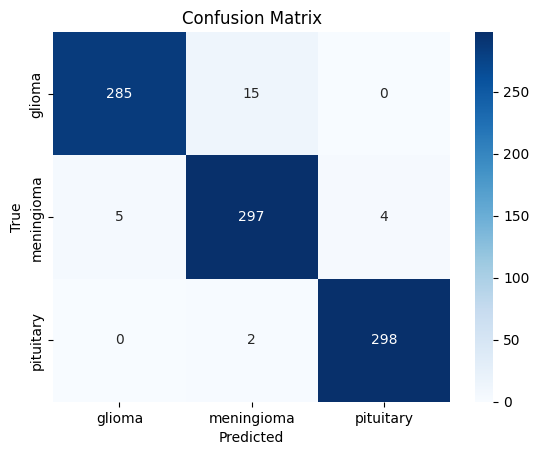

In [10]:
# ===========================
# 8️⃣ EVALUATION
# ===========================
model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, preds = outputs.max(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()